Homework 2:

In [1]:
import pandas as pd
import numpy as np

In [2]:
data = "https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv"

In [3]:
!wget $data

--2026-10-05 12:34:37--  https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 635180 (620K) [text/plain]
Saving to: ‘car_fuel_efficiency_2026.csv.1’

car_fuel_efficiency 100%[===================>] 620.29K  --.-KB/s    in 0.02s   

2026-10-05 12:34:37 (28.2 MB/s) - ‘car_fuel_efficiency_2026.csv.1’ saved [635180/635180]



In [4]:
df = pd.read_csv('car_fuel_efficiency_2026.csv')
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [5]:
df.columns

Index(['model_year', 'origin', 'fuel_type', 'drivetrain', 'num_doors',
       'engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration', 'fuel_efficiency_mpg'],
      dtype='str')

In [6]:
columns_to_use = ['engine_displacement','horsepower',
                  'vehicle_weight','model_year','fuel_efficiency_mpg']
df_filtered = df[columns_to_use]
df_filtered.head(2)

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3


EDA for fuel_efficiency_mpg:

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

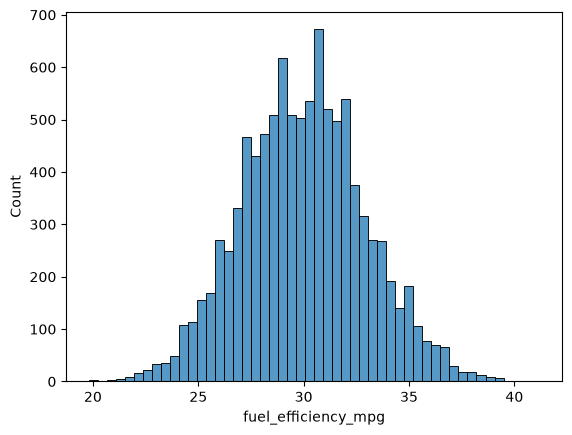

In [8]:
sns.histplot(df_filtered['fuel_efficiency_mpg'], bins=50)

fuel_efficiency_mpg doesn' have a long tail. It's distribution is likely to be a normal distribution.

Question 1:

In [9]:
df_filtered.isna().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

'horsepower' has  877 missing values.

Question 2:

In [10]:
df_filtered['horsepower'].median()

np.float64(254.0)

It's median value is 254.0

Prepare and split the dataset:

Question 3:

In [11]:
n = len(df_filtered)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df_filtered.iloc[idx[:n_train]]
df_val = df_filtered.iloc[idx[n_train:n_train + n_val]]
df_test = df_filtered.iloc[idx[n_train + n_val:]]

In [12]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [13]:
y_train = df_train['fuel_efficiency_mpg'].values
y_val = df_val['fuel_efficiency_mpg'].values
y_test = df_test['fuel_efficiency_mpg'].values

In [14]:
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [15]:
df_test.columns

Index(['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year'], dtype='str')

In [16]:
base = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']

In [17]:
mean_horse_train =  df_train['horsepower'].mean()

In [34]:
def prepare_X_ceros(df):
    df_cop = df.copy()
    df_num = df_cop[base]
    df_num['horsepower'] = df_num['horsepower'].fillna(0)
    X = df_num.values
    return X

In [35]:
def prepare_X_mean(df,mean):
    df_cop = df.copy()
    df_num = df_cop[base]
    df_num['horsepower'] = df_num['horsepower'].fillna(mean)
    X = df_num.values
    return X

In [20]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [21]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [22]:
#training for fillna with 0
X_train_0 = prepare_X_ceros(df_train)
w0_0, w_0= train_linear_regression(X_train_0, y_train)

In [23]:
w0_0

np.float64(-153.8849618823138)

In [24]:
w_0

array([-1.51505520e-03, -4.74024794e-06, -3.95418397e-03,  1.02146785e-01])

In [25]:
#training for fillna with train mean
X_train_mean = prepare_X_mean(df_train,mean_horse_train)
w0_m, w_m = train_linear_regression(X_train_mean, y_train)

In [30]:
#evaluation of fillna with 0
X_val_0 = prepare_X_ceros(df_val)
y_pred_0 = w0_0 + X_val_0.dot(w_0)
rmse_0 = round(rmse(y_val, y_pred_0),3)
print(rmse_0)

2.205


In [28]:
#evaluation of fillna with mean
X_val_m = prepare_X_mean(df_val,mean_horse_train)
y_pred_m = w0_m + X_val_m.dot(w_m)
rmse_m = round(rmse(y_val, y_pred_m),3)
print(rmse_m)

2.202


rmse with mean has a better result

Question 4:

In [31]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [33]:
for r in [0.0, 0.01, 0.1, 1, 5, 10, 100]:
    X_train_tune_0 = prepare_X_ceros(df_train)
    w0_tune_0, w_tune_0 = train_linear_regression_reg(X_train_tune_0, y_train, r=r)

    X_val_tune_0 = prepare_X_ceros(df_val)
    y_pred_tune_0 = w0_tune_0 + X_val_tune_0.dot(w_tune_0)
    score_tune_0 = round(rmse(y_val, y_pred_tune_0),4)
    
    print(r, w0_tune_0, score_tune_0)

0.0 -153.8849618823138 2.2053
0.01 -148.3092124404723 2.2058
0.1 -111.83871039306318 2.2241
1 -32.331865964971264 2.3492
5 -7.7728522099734025 2.4094
10 -3.9871164160193766 2.4195
100 -0.40821964884790385 2.4292


Best option for r is 0.0 with a RMSE of 2.2053

Question 5:

In [39]:
scores_q5 = []
for seed in [0,1,2,3,4,5,6,7,8,9]:
    #creation of the new split separation
    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    #data split
    df_train_q5 = df_filtered.iloc[idx[:n_train]]
    df_val_q5 = df_filtered.iloc[idx[n_train:n_train + n_val]]
    df_test_q5 = df_filtered.iloc[idx[n_train + n_val:]]

    #index rest
    df_train_q5 = df_train_q5.reset_index(drop=True)
    df_val_q5 = df_val_q5.reset_index(drop=True)
    df_test_q5 = df_test_q5.reset_index(drop=True)
    
    #new y
    y_train_q5 = df_train_q5['fuel_efficiency_mpg'].values
    y_val_q5 = df_val_q5['fuel_efficiency_mpg'].values
    y_test_q5 = df_test_q5['fuel_efficiency_mpg'].values

    del df_train_q5['fuel_efficiency_mpg']
    del df_val_q5['fuel_efficiency_mpg']
    del df_test_q5['fuel_efficiency_mpg']
    

    #q5 training
    X_train_q5 = prepare_X_ceros(df_train_q5)
    w0_q5, w_q5 = train_linear_regression(
        X_train_q5, y_train_q5)

    #q5 eval
    X_val_q5 = prepare_X_ceros(df_val_q5)
    y_pred_q5 = w0_q5 + X_val_q5.dot(w_q5)
    score_tune_q5 = round(rmse(y_val_q5, y_pred_q5),4)
    scores_q5.append(score_tune_q5)
    print(seed, w0_q5, score_tune_q5)

0 -150.42885945053604 2.2392
1 -151.61231559524532 2.2021
2 -152.84068112584038 2.1634
3 -152.33298096679098 2.2044
4 -158.8885681645812 2.2019
5 -151.8573533886124 2.2458
6 -154.3717913727048 2.2697
7 -155.01835258995723 2.1908
8 -150.4381740048234 2.2166
9 -154.3600748895819 2.207


In [40]:
std_q5 = round(np.std(scores_q5),3)
print(std_q5)

0.029


Standard deviation ofo the RMSE: 0.029 

Question 6:

In [41]:
#creation of the new split separation
np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

#data split
df_train_q6 = df_filtered.iloc[idx[:n_train]]
df_val_q6 = df_filtered.iloc[idx[n_train:n_train + n_val]]
df_test_q6 = df_filtered.iloc[idx[n_train + n_val:]]

#index rest
df_train_q6 = df_train_q6.reset_index(drop=True)
df_val_q6 = df_val_q6.reset_index(drop=True)
df_test_q6 = df_test_q6.reset_index(drop=True)
    
#new y
y_train_q6 = df_train_q6['fuel_efficiency_mpg'].values
y_val_q6 = df_val_q6['fuel_efficiency_mpg'].values
y_test_q6 = df_test_q6['fuel_efficiency_mpg'].values

del df_train_q6['fuel_efficiency_mpg']
del df_val_q6['fuel_efficiency_mpg']
del df_test_q6['fuel_efficiency_mpg']

#Combination of train and validation
df_full_train_q6 = pd.concat([df_train_q6, df_val_q6])
df_full_train_q6 = df_full_train_q6.reset_index(drop=True)

y_full_train_q6 = np.concatenate([y_train_q6, y_val_q6])


#q5 training
X_full_train_q6 = prepare_X_ceros(df_full_train_q6)
w0_q6, w_q6 = train_linear_regression_reg(
    X_full_train_q6, y_full_train_q6, r=0.001)

#q5 eval
X_test_q6 = prepare_X_ceros(df_test_q6)
y_pred_q6 = w0_q6 + X_test_q6.dot(w_q6)
score_q6 = round(rmse(y_test_q6, y_pred_q6),3)
print(score_q6)


2.236


The RMSE of the test dataset is 2.236